In [1]:

# Imports
import torch
import torch.optim as optim
from torchvision import datasets
from torch.utils.data import DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision import transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Custom dataset wrapper
from torch.utils.data import Dataset
import cv2

import torch.nn as nn
import torchvision.models as models
from torch.nn import TransformerEncoder, TransformerEncoderLayer

print("Imports completed.")

Imports completed.


In [2]:
# Config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img_size = 224
data_dir = "D:\\13. ML-research\\Datasets\\chest_xray_images"
class_names = ["bacterial", "normal", "viral"]
print("Device:", device)

Device: cpu


In [3]:
# Augmentation with Albumentations
from torchvision.datasets import ImageFolder

def get_transforms(phase):
    if phase == "train":
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.3),
            A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=10, p=0.4),
            A.CLAHE(p=0.1),
            A.OneOf([
                A.Blur(p=0.3),
                A.GaussianBlur(p=0.3),
                A.MotionBlur(p=0.3)
            ], p=0.3),
            A.Normalize(mean=(0.485, 0.456, 0.406),
                        std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=(0.485, 0.456, 0.406),
                        std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])

# Custom dataset wrapper
class CustomDataset(Dataset):
    def __init__(self, root, transform):
        self.data = datasets.ImageFolder(root=root)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        try:
            path, label = self.data.samples[idx]
            image = cv2.imread(path)
            if image is None:
                print(f"[WARNING] Couldn't read image: {path}")
                return self.__getitem__((idx + 1) % len(self.data))
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            augmented = self.transform(image=image)
            return augmented['image'], label
        except Exception as e:
            print(f"[ERROR] Error loading image at index {idx}: {e}")
            return self.__getitem__((idx + 1) % len(self.data))


In [4]:
# Load Data
import os
batch_size = 32

train_dataset = CustomDataset(os.path.join(data_dir, "train"), get_transforms("train"))
val_dataset   = CustomDataset(os.path.join(data_dir, "val"), get_transforms("val"))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
print("Data loaded successfully.")

print("Train size:", len(train_dataset), " | Val size:", len(val_dataset))


Data loaded successfully.
Train size: 5548  | Val size: 1188


In [5]:
# ResFormer Model Definition
class ResFormer(nn.Module):
    def __init__(self, num_classes=3):
        super(ResFormer, self).__init__()
        
        # Load pretrained ResNet50
        self.resnet = models.resnet50(pretrained=True)
        self.resnet.fc = nn.Identity()  # Remove final FC layer

        # Freeze early layers (optional for fine-tuning)
        for name, param in self.resnet.named_parameters():
            if "layer4" not in name:
                param.requires_grad = False

        # Transformer setup
        self.embedding_dim = 2048  # Output of resnet before FC
        encoder_layer = TransformerEncoderLayer(d_model=self.embedding_dim, nhead=8, dropout=0.1, batch_first=True)
        self.transformer = TransformerEncoder(encoder_layer, num_layers=2)

        # Final classification head
        self.classifier = nn.Sequential(
            nn.Linear(self.embedding_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Extract feature map using ResNet (before FC)
        features = self.resnet(x)  # [batch_size, 2048]
        features = features.unsqueeze(1)  # [batch_size, 1, 2048]
        features = self.transformer(features)  # [batch_size, 1, 2048]
        features = features.squeeze(1)  # [batch_size, 2048]
        out = self.classifier(features)
        return out

In [6]:
# Model, Optimizer, Scheduler
model = ResFormer(num_classes=3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)


d:\anaconda3\envs\pneumonia38\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\anaconda3\envs\pneumonia38\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
d:\anaconda3\envs\pneumonia38\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [7]:
from tqdm import tqdm

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=30):
    best_acc = 0
    history = {"train_acc": [], "val_acc": [], "train_loss": []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        print(f"\n### Epoch {epoch+1}/{epochs} ###")
        progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), desc="Training", leave=True)

        for i, (imgs, labels) in progress_bar:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

            # Show intermediate progress every 10% of batches
            if (i + 1) % (len(train_loader) // 10 + 1) == 0:
                progress_bar.set_postfix({
                    "Loss": f"{train_loss / (i+1):.4f}",
                    "Acc": f"{100. * correct / total:.2f}%",
                    "LR": optimizer.param_groups[0]['lr']
                })

        train_acc = 100. * correct / total

        # Validation
        model.eval()
        correct_val, total_val = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, preds = outputs.max(1)
                correct_val += preds.eq(labels).sum().item()
                total_val += labels.size(0)

        val_acc = 100. * correct_val / total_val
        scheduler.step(val_acc)

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_loss"].append(train_loss / len(train_loader))

        print(f"--> Epoch {epoch+1} Summary -> Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")
            print("<--> New best model saved!")

    print(f"\n--> Training completed. Best Validation Accuracy: {best_acc:.2f}%")
    return history


In [8]:
#  Plot Accuracy and Loss
def plot_history(history):
    epochs = range(1, len(history["train_acc"]) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy Over Epochs")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()
    print("--> Training history plotted.")




### Epoch 1/30 ###


Training: 100%|██████████| 174/174 [15:38<00:00,  5.40s/it, Loss=0.5567, Acc=77.18%, LR=0.0001]


--> Epoch 1 Summary -> Train Acc: 77.74%, Val Acc: 83.67%
<--> New best model saved!

### Epoch 2/30 ###


Training: 100%|██████████| 174/174 [14:23<00:00,  4.96s/it, Loss=0.4303, Acc=81.73%, LR=0.0001]


--> Epoch 2 Summary -> Train Acc: 81.69%, Val Acc: 82.83%

### Epoch 3/30 ###


...

--> Epoch 28 Summary -> Train Acc: 95.93%, Val Acc: 90.57%
<--> New best model saved!

### Epoch 29/30 ###


Training: 100%|██████████| 174/174 [13:55<00:00,  4.80s/it, Loss=0.0998, Acc=96.39%, LR=2.5e-5]


--> Epoch 29 Summary -> Train Acc: 96.41%, Val Acc: 89.98%

### Epoch 30/30 ###


Training: 100%|██████████| 174/174 [13:20<00:00,  4.60s/it, Loss=0.1044, Acc=95.99%, LR=2.5e-5]


--> Epoch 30 Summary -> Train Acc: 96.02%, Val Acc: 88.72%

--> Training completed. Best Validation Accuracy: 90.57%


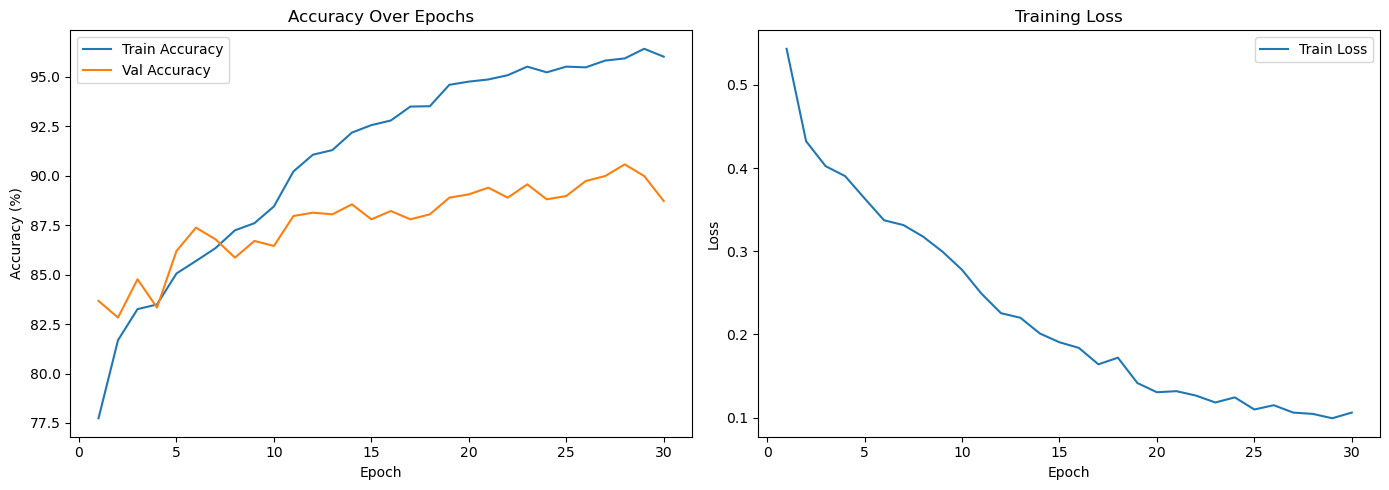

--> Training history plotted.


In [9]:
# Train the model and plot history
history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=30)
plot_history(history)